In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
%%writefile plate.yaml
train: /kaggle/input/datasets/hoangvudinh0301/plate-keypoints-dataset/train/images
val: /kaggle/input/datasets/hoangvudinh0301/plate-keypoints-dataset/valid/images

kpt_shape: [4, 3]

names:
  0: plate

Writing plate.yaml


In [3]:
from ultralytics import YOLO

model = YOLO("yolo11s-pose.pt")

results = model.train(
    data="plate.yaml", 
    epochs=100, 
    imgsz=1024,    
    batch=16,
    degrees=20.0,       
    shear=15.0,          
    perspective=0.001,
    scale=0.5,          
    fliplr=0.0,         
    mosaic=1.0,         
    mixup=0.1,         
    device=0            
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plate.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=Fals

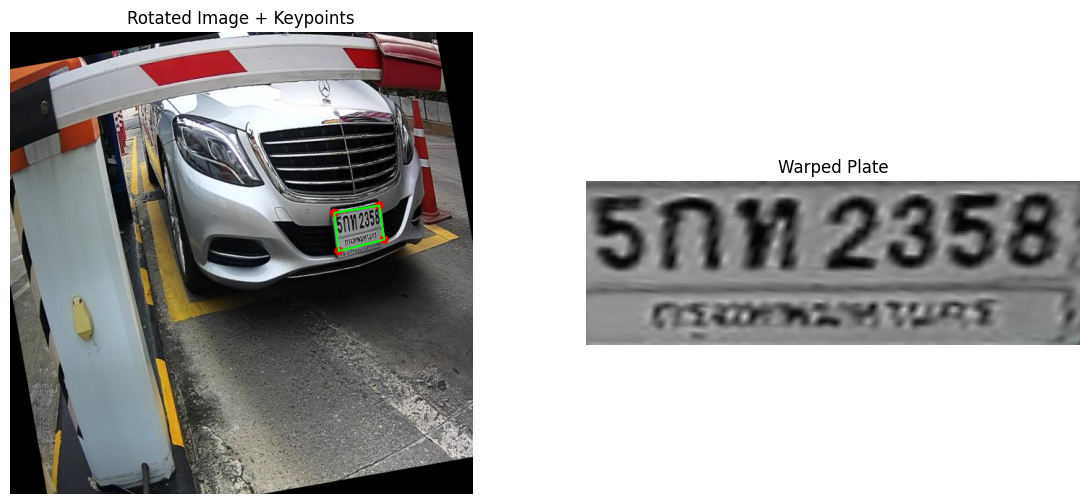

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# =========================
# LOAD MODEL
# =========================
model = YOLO("/kaggle/working/runs/pose/train/weights/best.pt")

# =========================
# LOAD IMAGE
# =========================
img = cv2.imread("/kaggle/input/datasets/hoangvudinh0301/keypoints/test/images/25e3c1b95844ebf2_cam2_jpg.rf.aced3af3ebc59898a0cb5debb844802f.jpg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# =========================
# ROTATE IMAGE FIRST
# =========================
h, w = img.shape[:2]

angle = 10

M_rotate = cv2.getRotationMatrix2D(
    (w // 2, h // 2),
    angle,
    1.0
)

rotated = cv2.warpAffine(
    img,
    M_rotate,
    (w, h)
)

# =========================
# PREDICT ON ROTATED IMAGE
# =========================
results = model.predict(
    rotated,
    conf=0.5,
    imgsz=640,
    verbose=False
)

# =========================
# PROCESS RESULT
# =========================
for r in results:

    keypoints = r.keypoints.xy.cpu().numpy()

    for kpts in keypoints:

        pts = np.array(kpts, dtype=np.float32)

        # =====================
        # DRAW DETECTION
        # =====================
        draw = rotated.copy()

        for x, y in pts:

            cv2.circle(
                draw,
                (int(x), int(y)),
                6,
                (255,0,0),
                -1
            )

        cv2.polylines(
            draw,
            [pts.astype(np.int32)],
            True,
            (0,255,0),
            2
        )

        # =====================
        # WARP PLATE
        # =====================
        width = 300
        height = 100

        dst = np.array([
            [0,0],
            [width,0],
            [width,height],
            [0,height]
        ], dtype=np.float32)

        M = cv2.getPerspectiveTransform(
            pts,
            dst
        )

        warp = cv2.warpPerspective(
            rotated,
            M,
            (width, height)
        )

        # =====================
        # SHOW
        # =====================
        plt.figure(figsize=(14,6))

        plt.subplot(1,2,1)
        plt.imshow(draw)
        plt.title("Rotated Image + Keypoints")
        plt.axis("off")

        plt.subplot(1,2,2)
        plt.imshow(warp)
        plt.title("Warped Plate")
        plt.axis("off")

        plt.show()